# EDA：好球判定率 2D 熱圖

第一階段 EDA。資料來源 `data/processed/statcast_2023.parquet`（由 `data/fetch.py` 產生），
只含主審判定球（called strike / ball）。

核心產出：在 `plate_x` × 標準化 `plate_z` 網格上，畫每格的 **called-strike 比例**，
看出好球帶的實證形狀與模糊邊界。

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
# 中文字型（macOS）；unicode_minus=False 讓負號正常顯示
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

DATA = Path('..') / 'data' / 'processed' / 'statcast_2023.parquet'
df = pl.read_parquet(DATA)
print(f'{len(df):,} 顆判定球')
df.head()

358,480 顆判定球


game_date,game_type,game_pk,pitcher,batter,fielder_2,stand,p_throws,balls,strikes,plate_x,plate_z,sz_top,sz_bot,description,plate_z_std,is_strike
str,str,i64,i64,i64,i64,str,str,i64,i64,f64,f64,f64,f64,str,f64,i8
"""2023-03-31""","""R""",718771,640462,592192,663743,"""R""","""L""",0,0,0.017651,2.379633,3.28777,1.580001,"""called_strike""",0.468232,1
"""2023-03-31""","""R""",718771,640462,596019,663743,"""R""","""L""",0,0,-0.577526,1.262705,3.336489,1.591558,"""called_strike""",-0.188462,1
"""2023-03-31""","""R""",718771,595928,624585,553882,"""R""","""R""",0,0,2.212413,1.195835,3.611182,1.697412,"""ball""",-0.262088,0
"""2023-03-31""","""R""",718771,595928,665862,553882,"""L""","""R""",1,1,1.402476,0.321262,3.864018,1.856401,"""ball""",-0.764658,0
"""2023-03-31""","""R""",718771,595928,665862,553882,"""L""","""R""",0,1,1.187945,3.174351,3.798431,1.739998,"""ball""",0.696818,0


## 基本統計

In [2]:
print('整體好球率:', round(df['is_strike'].mean(), 4))
print('唯一捕手數 (fielder_2):', df['fielder_2'].n_unique())
print('日期範圍:', df['game_date'].min(), '~', df['game_date'].max())
print()
print('好球率 by 打者側 (stand):')
print(df.group_by('stand').agg(pl.col('is_strike').mean().round(4), pl.len()).sort('stand'))

整體好球率: 0.3289
唯一捕手數 (fielder_2): 102
日期範圍: 2023-03-30 ~ 2023-10-01

好球率 by 打者側 (stand):
shape: (2, 3)
┌───────┬───────────┬────────┐
│ stand ┆ is_strike ┆ len    │
│ ---   ┆ ---       ┆ ---    │
│ str   ┆ f64       ┆ u32    │
╞═══════╪═══════════╪════════╡
│ L     ┆ 0.3225    ┆ 152357 │
│ R     ┆ 0.3336    ┆ 206123 │
└───────┴───────────┴────────┘


## 2D 好球判定率熱圖

座標從**捕手/主審視角**（打者站在畫面，`plate_x` 正值為捕手右側）。
縱軸用標準化 `plate_z`：0 = 好球帶下緣、1 = 上緣，虛線框為名義好球帶。
只畫每格樣本數足夠（≥ min_count）的網格，避免邊緣雜訊。

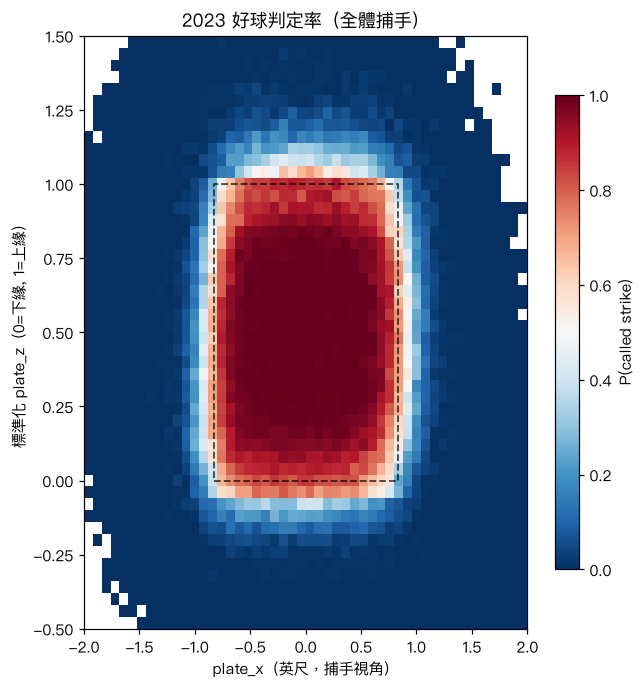

In [3]:
def strike_rate_heatmap(
    data: pl.DataFrame,
    z_col: str = 'plate_z_std',
    x_range=(-2.0, 2.0),
    z_range=(-0.5, 1.5),
    bins: int = 50,
    min_count: int = 20,
    ax=None,
    title: str | None = None,
):
    """在 (plate_x, z_col) 網格畫 called-strike 比例熱圖。"""
    x = data['plate_x'].to_numpy()
    z = data[z_col].to_numpy()
    s = data['is_strike'].to_numpy()

    x_edges = np.linspace(*x_range, bins + 1)
    z_edges = np.linspace(*z_range, bins + 1)

    # 每格好球數與總數 → 比例
    strike_sum, _, _ = np.histogram2d(x, z, bins=[x_edges, z_edges], weights=s)
    total, _, _ = np.histogram2d(x, z, bins=[x_edges, z_edges])
    with np.errstate(invalid='ignore', divide='ignore'):
        rate = strike_sum / total
    rate[total < min_count] = np.nan

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6.5))
    mesh = ax.pcolormesh(x_edges, z_edges, rate.T, cmap='RdBu_r', vmin=0, vmax=1, shading='flat')

    # 名義好球帶：plate_x 半寬約 0.83ft（本壘板 17" + 球半徑），標準化 z 為 0~1
    zone_x = 0.83
    if z_col == 'plate_z_std':
        z_lo, z_hi = 0.0, 1.0
    else:
        z_lo, z_hi = 1.5, 3.5  # 概略名義好球帶（原始英尺）
    ax.plot([-zone_x, zone_x, zone_x, -zone_x, -zone_x],
            [z_lo, z_lo, z_hi, z_hi, z_lo], 'k--', lw=1.2, alpha=0.7)

    ax.set_xlabel('plate_x（英尺，捕手視角）')
    ax.set_ylabel('標準化 plate_z（0=下緣, 1=上緣）' if z_col == 'plate_z_std' else 'plate_z（英尺）')
    ax.set_aspect('equal' if z_col != 'plate_z_std' else 'auto')
    ax.set_title(title or 'Called-strike 比例')
    return ax, mesh

fig, ax = plt.subplots(figsize=(6.5, 7))
_, mesh = strike_rate_heatmap(df, ax=ax, title='2023 好球判定率（全體捕手）')
fig.colorbar(mesh, ax=ax, label='P(called strike)', shrink=0.8)
Path('../figures').mkdir(exist_ok=True)
fig.savefig('../figures/strike_rate_heatmap_2023.png', bbox_inches='tight')
plt.show()

## 依打者左右打分面

左右打者好球帶會有水平位移（外角/內角判定不對稱），分面看差異。

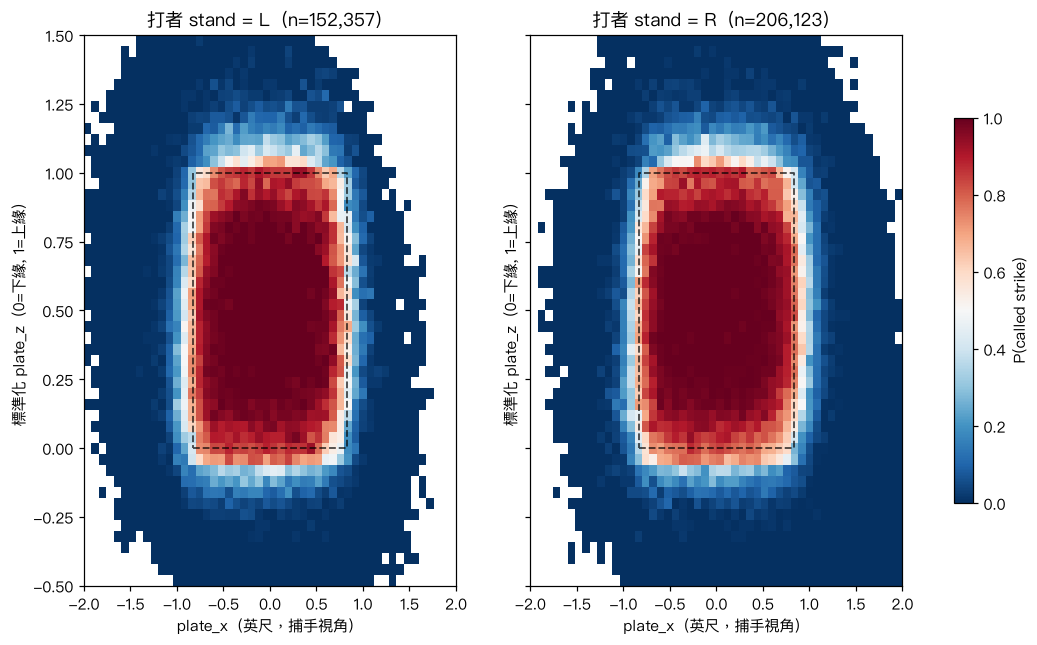

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)
for ax, side in zip(axes, ['L', 'R']):
    sub = df.filter(pl.col('stand') == side)
    _, mesh = strike_rate_heatmap(sub, ax=ax, title=f'打者 stand = {side}（n={len(sub):,}）')
fig.colorbar(mesh, ax=axes, label='P(called strike)', shrink=0.7)
fig.savefig('../figures/strike_rate_by_stand_2023.png', bbox_inches='tight')
plt.show()

## 判定率隨球數變化

著名現象：投手領先球數（如 0-2）主審好球帶**縮小**，打者領先球數（如 3-0）**放大**。
先看各球數的整體好球率矩陣（列 = 壞球數、欄 = 好球數）。

In [5]:
by_count = (df.group_by(['balls', 'strikes'])
             .agg(pl.col('is_strike').mean().alias('strike_rate'), pl.len().alias('n'))
             .sort(['balls', 'strikes']))
matrix = (by_count.pivot(values='strike_rate', index='balls', on='strikes')
                  .sort('balls'))
print('好球率矩陣（列=壞球, 欄=好球）:')
print(matrix)
print('\n最極端對比：0-2 =',
      round(by_count.filter((pl.col('balls')==0) & (pl.col('strikes')==2))['strike_rate'][0], 3),
      'vs 3-0 =',
      round(by_count.filter((pl.col('balls')==3) & (pl.col('strikes')==0))['strike_rate'][0], 3))

好球率矩陣（列=壞球, 欄=好球）:
shape: (4, 4)
┌───────┬──────────┬──────────┬──────────┐
│ balls ┆ 0        ┆ 1        ┆ 2        │
│ ---   ┆ ---      ┆ ---      ┆ ---      │
│ i64   ┆ f64      ┆ f64      ┆ f64      │
╞═══════╪══════════╪══════════╪══════════╡
│ 0     ┆ 0.455716 ┆ 0.224476 ┆ 0.081193 │
│ 1     ┆ 0.418953 ┆ 0.25122  ┆ 0.099918 │
│ 2     ┆ 0.468178 ┆ 0.312348 ┆ 0.143575 │
│ 3     ┆ 0.629143 ┆ 0.399827 ┆ 0.237261 │
└───────┴──────────┴──────────┴──────────┘

最極端對比：0-2 = 0.081 vs 3-0 = 0.629


### 兩極球數熱圖：0-2 vs 3-0

直接比較好球帶最緊（0-2）與最鬆（3-0）的實證形狀。
3-0 樣本較少，用較粗網格與較低 min_count。

注意 0-2 好球帶**內部**的雜色斑塊：0-2 時打者對中間球幾乎都揮棒，
「被主審判定（take）的中間球」樣本極少，格內雜訊大——這是選擇性揮棒造成的取樣假象，
不是好球帶真的破洞。下面控制位置的差異圖能繞過這個問題。

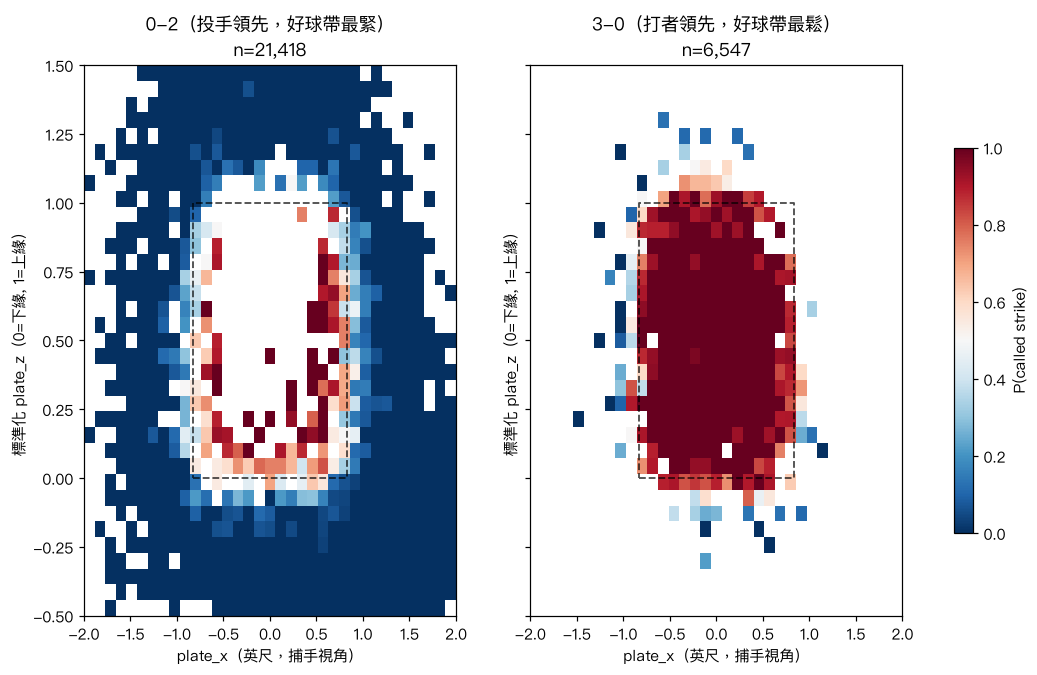

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)
specs = [((0, 2), '0-2（投手領先，好球帶最緊）'),
         ((3, 0), '3-0（打者領先，好球帶最鬆）')]
for ax, ((b, s), label) in zip(axes, specs):
    sub = df.filter((pl.col('balls') == b) & (pl.col('strikes') == s))
    _, mesh = strike_rate_heatmap(sub, ax=ax, bins=35, min_count=8,
                                  title=f'{label}\nn={len(sub):,}')
fig.colorbar(mesh, ax=axes, label='P(called strike)', shrink=0.7)
fig.savefig('../figures/strike_rate_02_vs_30_2023.png', bbox_inches='tight')
plt.show()

### 球數差異圖（控制位置）

邊際好球率的差異混入了不同球數的**進壘位置分布**（3-0 球多塞中間）。
要單獨看主審的球數偏誤，須在**相同位置格**上相減。
下圖 = 打者領先球數(balls>strikes) 減 投手領先球數(strikes>balls) 的每格好球率差，
紅色代表「同一位置，打者領先時更容易被判好球」——即好球帶向外擴張的地帶。

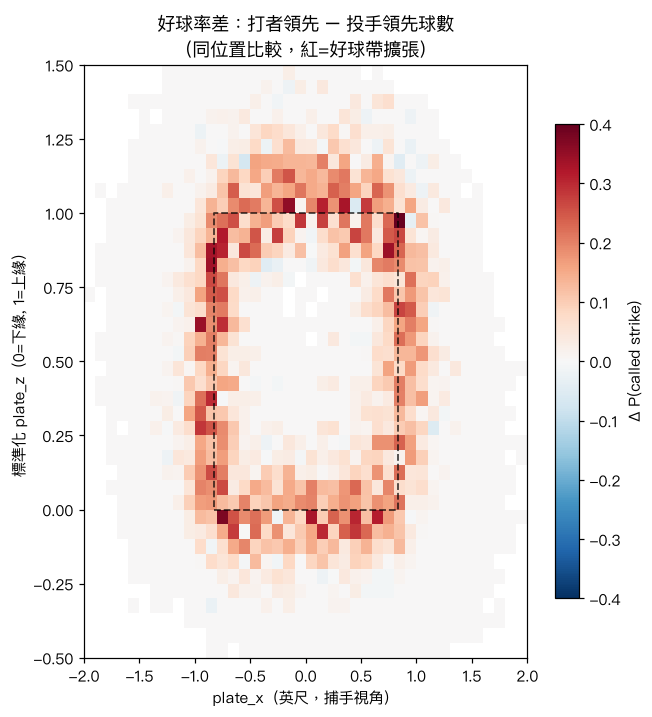

In [7]:
def strike_rate_grid(data, x_range=(-2.0, 2.0), z_range=(-0.5, 1.5), bins=40, min_count=15):
    x = data['plate_x'].to_numpy(); z = data['plate_z_std'].to_numpy(); s = data['is_strike'].to_numpy()
    xe = np.linspace(*x_range, bins + 1); ze = np.linspace(*z_range, bins + 1)
    ssum, _, _ = np.histogram2d(x, z, bins=[xe, ze], weights=s)
    tot, _, _ = np.histogram2d(x, z, bins=[xe, ze])
    with np.errstate(invalid='ignore', divide='ignore'):
        rate = ssum / tot
    rate[tot < min_count] = np.nan
    return rate, xe, ze

hitter = df.filter(pl.col('balls') > pl.col('strikes'))
pitcher = df.filter(pl.col('strikes') > pl.col('balls'))
r_h, xe, ze = strike_rate_grid(hitter)
r_p, _, _ = strike_rate_grid(pitcher)
diff = r_h - r_p

fig, ax = plt.subplots(figsize=(6.5, 7))
mesh = ax.pcolormesh(xe, ze, diff.T, cmap='RdBu_r', vmin=-0.4, vmax=0.4, shading='flat')
ax.plot([-0.83, 0.83, 0.83, -0.83, -0.83], [0, 0, 1, 1, 0], 'k--', lw=1.2, alpha=0.7)
ax.set_xlabel('plate_x（英尺，捕手視角）')
ax.set_ylabel('標準化 plate_z（0=下緣, 1=上緣）')
ax.set_title('好球率差：打者領先 − 投手領先球數\n（同位置比較，紅=好球帶擴張）')
fig.colorbar(mesh, ax=ax, label='Δ P(called strike)', shrink=0.8)
fig.savefig('../figures/strike_rate_count_diff_2023.png', bbox_inches='tight')
plt.show()

## 觀察

- 好球帶核心（深紅，P→1）與外圍壞球區（深藍，P→0）之間有一圈**過渡帶**——這正是 framing 發揮作用的邊界地帶，也是後續 GAM 要平滑建模的區域。
- 名義好球帶（虛線框）與 50% 等機率線並不完全重合，實證好球帶通常略偏移/變形。
- **球數效應**：0-2 邊際好球率僅約 8%、3-0 高達約 63%；但這混入了位置分布差異。控制位置後的差異圖顯示——同一位置，打者領先球數時好球帶**沿邊緣向外擴張**，核心區則差異很小（本來就穩定判好球）。
- 下一步（週 4）：用 GAM 對這個曲面平滑建模，把位置、打者側、球數一起放進去，畫出各球數下的 50% 等高線，量化上面看到的球數偏誤。